In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here

    # Hard-coding gamma values according to specification
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]

    output = pd.DataFrame(columns = ['gamma', 'R0', 'peak_infected','peak_day','total_deaths'])

    # Specifying the model
    def sird_model(y, t, beta, gamma, mu):
        """
        """
        S, I, R, D = y
        N = S + I + R + D



        dSdt = - beta * S * I / N
        dIdt = beta * S * I / N - gamma * I - mu * I
        dRdt = gamma * I
        dDdt = mu * I

        return dSdt, dIdt, dRdt, dDdt

    # Initial parameters setup
    t = np.linspace(0, simulation_days - 1, simulation_days)

    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    # Track specifically the epidemic curves for plotting
    I_curves = []


    # Simulate for each gamma value
    for i,gamma in enumerate(gamma_values):
        sol = odeint(sird_model,y0,t,args=(beta, gamma, mu))
        S, I, R, D = sol.T

        R0 = beta/gamma
        peak_infected = int(max(I))
        peak_day = np.argmax(I)
        total_deaths = int(D[-1])

        output.loc[i] = {'gamma': gamma, 'R0': R0, 'peak_infected': peak_infected, 'peak_day': peak_day, 'total_deaths': total_deaths}

        I_curves.append(I)


    # Nested plotting function
    def plot_infected_curves(I_curves, gamma_values, beta, mu, N, simulation_days):
        t = np.linspace(0, simulation_days - 1, simulation_days)
        plt.figure(figsize=(10, 6))
        for i, gamma in enumerate(gamma_values):
            plt.plot(t, I_curves[i], label=r"$\gamma = {gamma}$".format(gamma=gamma))
        plt.xlabel('Days')
        plt.ylabel('Number of infected')
        plt.title('Epidemic curves for different recovery rates\n' + r'$\beta={beta}, \mu={mu}, N={N}$'.format(beta=beta, mu=mu, N=N))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    plot_infected_curves(I_curves, gamma_values, beta, mu, N, simulation_days)
    return output

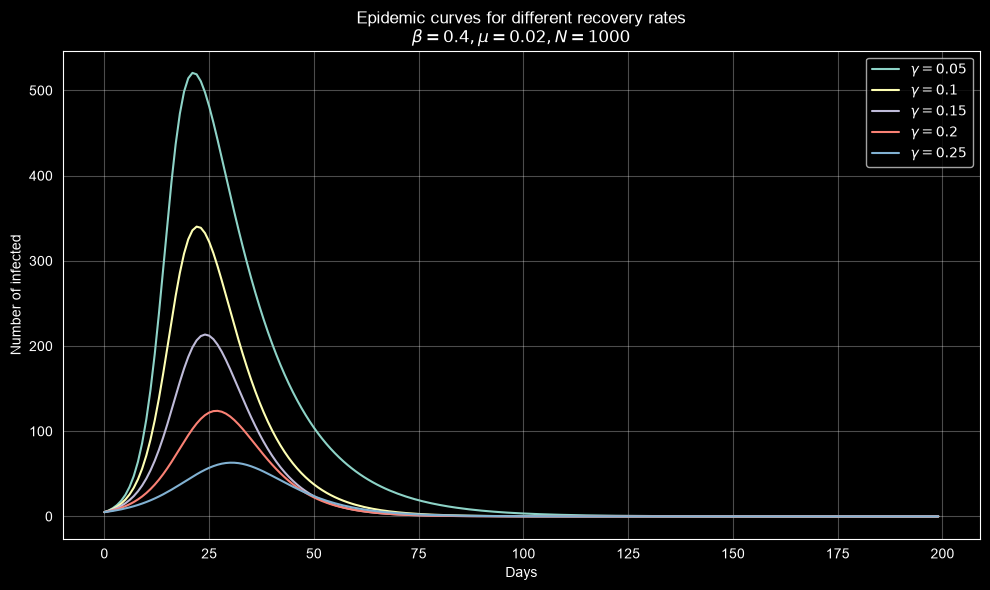

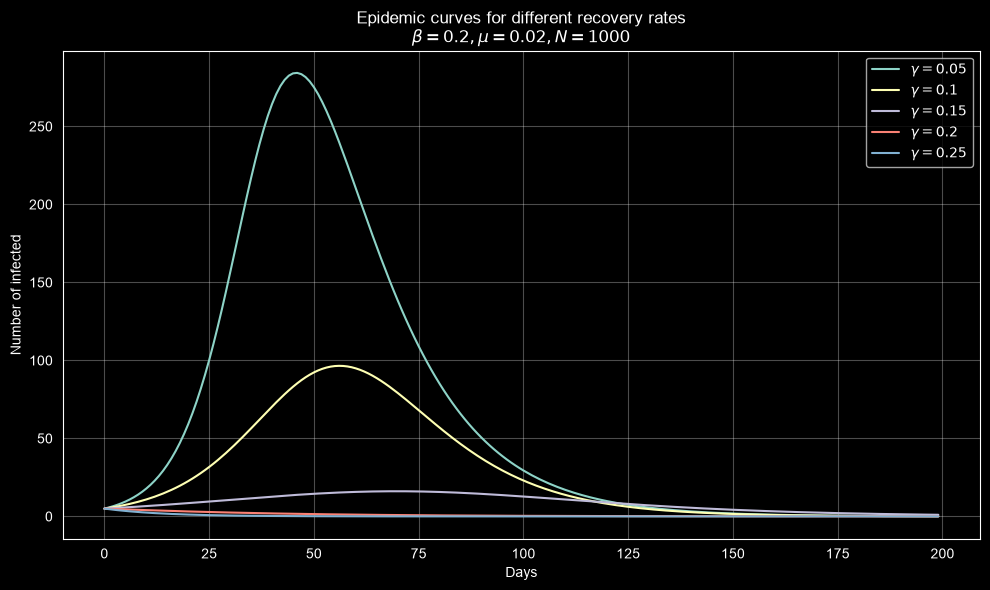

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  8.000000            520        21           284
1   0.10  4.000000            340        22           159
2   0.15  2.666667            213        24           102
3   0.20  2.000000            123        27            67
4   0.25  1.600000             63        30            42

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  4.000000            284        46           265
1   0.10  2.000000             96        56           113
2   0.15  1.333333             16        70            35
3   0.20  1.000000              5         0             3
4   0.25  0.800000              5         0             1


In [12]:
# Scenario 1 (high transmition): beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
scenario1 = analyze_recovery_rates(0.4,0.02,1000, 5, 200)

# Scenario 2 (low transmition): beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200
scenario2 = analyze_recovery_rates(0.2,0.02,1000, 5, 200)

print(scenario1)
print()
print(scenario2)




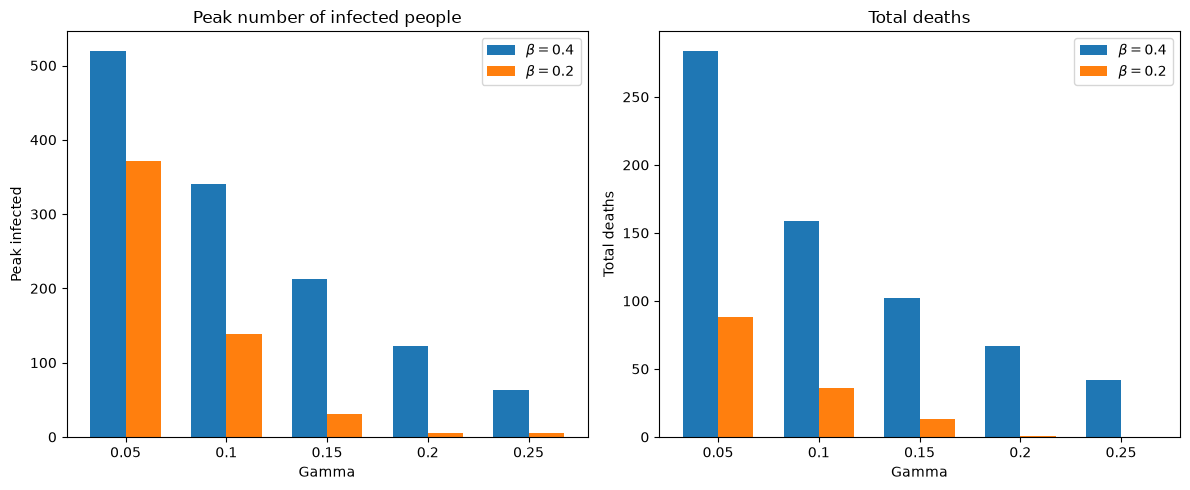

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Example names — replace these with your actual transmission rates
transmission_rate_1 = r"$\beta = 0.4$"
transmission_rate_2 = r"$\beta = 0.2$"

# Gamma values
gamma = scenario1["gamma"]

# Width of each bar
width = 0.35

# Positions on x-axis
x = np.arange(len(gamma))

# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# 1. Peak infected
# -------------------------
axes[0].bar(
    x - width/2,
    scenario1["peak_infected"],
    width,
    label=transmission_rate_1
)

axes[0].bar(
    x + width/2,
    scenario2["peak_infected"],
    width,
    label=transmission_rate_2
)

axes[0].set_xlabel("Gamma")
axes[0].set_ylabel("Peak infected")
axes[0].set_title("Peak number of infected people")
axes[0].set_xticks(x)
axes[0].set_xticklabels(gamma)
axes[0].legend()

# -------------------------
# 2. Total deaths
# -------------------------
axes[1].bar(
    x - width/2,
    scenario1["total_deaths"],
    width,
    label=transmission_rate_1
)

axes[1].bar(
    x + width/2,
    scenario2["total_deaths"],
    width,
    label=transmission_rate_2
)

axes[1].set_xlabel("Gamma")
axes[1].set_ylabel("Total deaths")
axes[1].set_title("Total deaths")
axes[1].set_xticks(x)
axes[1].set_xticklabels(gamma)
axes[1].legend()

# Improve layout
plt.tight_layout()
plt.show()

#### Analysis

The first codition is worse for public heatlh than the second one. Two main reasons for this: 

The first is that the peak of infected people is systematically higher (regardless of the gamma being modeled), which means that hospitals will have to take care of more people at once, this may lead to overwhelmed hospitals. This in turn will probably affect the quality of the care being given in those hospitals, and so result in a less efficient recovery for sick people.

Another reason why the first is worse is that the total number of dead people is also systematically higher. This can effect the moral (mental state) of the medical staff.

As a conclusion the first scenario where transmission is high, is likelier to wear out people working in public health, both phyiscally and psychologically, which is bound to have a negative effect on their work.

### Part 3
#### 3.1

Increasing the recovery rate ($\gamma$) has an strong negative relationship with both peak infections and total deaths. In the first set of results, increasing $\gamma$ from 0.05 to 0.25 reduces the peak number of infected people from 158 to 10, a decrease of 148 people or approximately 94%. Total deaths decrease from 533 to 16, which is a reduction of approximately 97%. Peak infections decrease consistently by around 56–67% for every 0.05 increase until $\gamma=0.20$, after which the peak remains stable at 10. Total deaths also decrease strongly, by roughly 45–68% for each 0.05 increase in $\gamma$.

The same relationship is visible in both transmission scenarios, with some slight variation. In the high transmission scenario, peak infections decrease from 520 to 63 as $\gamma$ increases from 0.05 to 0.25, corresponding to an approximately 88% reduction. Deaths decrease from 284 to 42, or approximately 85%. In the low transmission scenario, the effect is even stronger, peak infections decrease from 371 to 5, approximately 99%, while deaths decrease from 88 to 0. This suggests that increasing the recovery rate may be more effective at controlling the epidemic when the transmission rate is already relatively low.

In the high transmission scenario, the peak becomes smaller but occurs later, moving from day 21 at $\gamma=0.05$ to day 30 at $\gamma=0.25$ . A similar pattern initially occurs in the low transmission scenario, where the peak moves from day 44 to day 67 as $\gamma$ increases from 0.05 to 0.15. However, at $\gamma=0.20$ and $\gamma=0.25$, the recorded peak changes suddenly to day 0. This indicates that the initial number of infected people is already the maximum and that the infection does not grow into a larger epidemic. The same behaviour is seen in the first set of results, where the peak changes to day 0 at the two highest recovery rates.

In general, a higher recovery rate is expected to shorten the epidemic because infected individuals leave the infected compartment more quickly. The results appear to stabilize at the highest tested recovery rates, particularly between $\gamma=0.20$ and $\gamma=0.25$. However, more values above $\gamma=0.25$ would be needed to determine whether this pattern continues, especially given the consistent increase in peak day observed in the high transmission scenario.

In conclusion, increasing the recovery rate reduces peak infections and deaths. Its effect on the timing of the epidemic is not linear. At lower and intermediate recovery rates, the epidemic peak may occur later while becoming smaller, while at sufficiently high recovery rates the outbreak may no longer grow beyond the initially infected population, which suggests that the epidemic may also become shorter.

#### 3.2

Using Scenario A as the baseline, if a recovery rate of $\gamma=0.10$ results in 159 total deaths and an intervention increases the recovery rate by 50%, the new recovery rate would be:

$$
0.10 \times 1.5 = 0.15
$$

At $\gamma=0.15$, Scenario A results in 102 total deaths. Therefore, the intervention would reduce the expected number of deaths by:

$$
159 - 102 = 57
$$

This results in a percentage reduction of:

$$
\frac{57}{159}\times100 \approx 35.8\%
$$

Therefore, a 50% increase in recovery rate has approximately 57 fewer deaths, or a 36% reduction in total deaths, in Scenario A. This suggests that interventions that allow infected individuals to recover more quickly  could have a postivie effect on survival.

(used baseline recovery rate of 0.1 because it is the only tested value that has another tested value when increasing the rate by 50%)

#### 3.3
A real medical intervention that could increase the recovery rates is oseltamivir (Tamiflu) a medicine specified in treating influenza. Oseltamivir is a neuraminidase inhibitor, meaning that it blocks a protein that influenza viruses need to release newly formed virus particles from infected cells. By reducing further viral spread within the body, the treatment can reduce the duration of influenza symptoms.

When started within 48 hours after symptoms appear oseltamivir can shorten influenza illness by approximately one day. This estimate can be represented in the SIRD model as an increase in the recovery rate ($\gamma$). For illustration, lets assume that an untreated influenza infection lasts approximately 6 days.

The corresponding untreated recovery rate would be:

$$
\gamma_{\text{untreated}} = \frac{1}{6} \approx 0.167
$$

If oseltamivir reduces the illness duration by approximately one day, the duration would decrease from 6 to 5 days:

$$
\gamma_{\text{treated}} = \frac{1}{5} = 0.20
$$

Hence, the relative increase in recovery rate would be:

$$
\frac{0.20 - 0.167}{0.167} \times 100 \approx 20\%
$$

Under this simplified assumption, shortening illness duration by one day could be represented as approximately a 20% increase in the recovery rate $\gamma$.

However, this is only an approximation. The effectiveness of oseltamivir depends strongly on how early treatment is started and can vary between patients. In addition, symptom duration is not exactly the same as the infectious period represented by $\gamma$ in the SIRD model. This model assumes one constant recovery rate for the whole infected population, while real patients differ in age, disease severity, health conditions and response to treatment. Therefore, representing oseltamivir as a 20% increase in $\gamma$ is useful for imagining its possible effect in the model, but it should not be interpreted as an exact real-world treatment effect.